## SWE - Synthesis - SOLUTION

We solved the same 1D bump-pulse step with multiple tools: NumPy, JAX, PyOMP,
nanobind, CuPy, CppJIT, and mpi4py. This notebook reads `timings.json` and compares them on first-call
compile cost and on a matched-float64 throughput sweep from cache-resident to
DRAM-resident sizes, closing with a which-tool-when reference table.

**SOLUTION**

### Table of Contents

1. [Read the timings](#sec1)
2. [First-call compile cost](#sec2)
3. [Matched-precision comparison across the memory hierarchy](#sec3)
4. [Reference: which tool when](#sec4)

### <a id="sec1"></a>1. Read the timings

We load every row from `timings.json` (written by NB 08-08). Each row
carries the warm wall-clock (`median_s`), the first-call cost where the
tool JIT-compiles (`cold_s`), the hardware and dtype it ran on, and the
max-diff against the float64 NumPy reference.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import swe_core

rows = swe_core.load_timings()
by_tool = {r["tool"]: r for r in rows}

# timings.json is written by notebooks 08 to 13
expected = ["numpy", "cupy", "cupy_fused", "jax", "jax_fp64", "pyomp",
            "nanobind", "cppjit_gpu_cub", "cppjit_gpu_raw", "mpi4py"]
missing = [t for t in expected if t not in by_tool]
if missing:
    raise SystemExit(
        "timings.json has no rows for: " + ", ".join(missing) + ". "
        "Run notebooks 08 through 13 first, then re-run this notebook."
    )

hdr = (f'{"stage":<24}{"tool":>18}{"hardware":>9}{"dtype":>9}'
       f'{"median_s":>11}{"cold_s":>9}{"max_diff":>12}')
print(hdr)
print("-" * len(hdr))
for r in rows:
    cold = r.get("cold_s", float("nan"))
    md = r.get("max_diff_vs_numpy")
    md_s = f"{md:.1e}" if md is not None else ("ref" if r["tool"] == "numpy" else "n/a")
    print(f'{r["stage"]:<24}{r["tool"]:>18}{r["hardware"]:>9}{r["dtype"]:>9}'
          f'{r["median_s"]:>11.4f}{cold:>9.3f}{md_s:>12}')

stage                                 tool hardware    dtype   median_s   cold_s    max_diff
--------------------------------------------------------------------------------------------
08_numpy                             numpy      cpu  float64     0.1650      nan         ref
10_pyomp                             pyomp      cpu  float64     0.0205    0.156     0.0e+00
12_cppjit_gpu_cub           cppjit_gpu_cub      gpu  float64     0.0158    0.110     1.6e-15
12_cupy                               cupy      gpu  float64     0.2695    0.288     0.0e+00
12_cupy_fused                   cupy_fused      gpu  float64     0.0089    0.010     1.3e-15
12_cppjit_gpu_raw           cppjit_gpu_raw      gpu  float64     0.0095    0.025     1.6e-15
09_jax                                 jax      gpu  float32     0.0141    0.557     1.5e-05
09_jax_fp64                       jax_fp64      gpu  float64     0.0819      nan     0.0e+00
11_nanobind                       nanobind      cpu  float64     0.006

### <a id="sec2"></a>2. First-call compile cost

Cold time is the first call, where CuPy, JAX, PyOMP, and CppJIT pay a compile
cost before they execute; warm is the steady-state median over repeated runs
(`N = 16384`, 1000 steps). The JAX bars are its native float32 run;
the rest are float64. nanobind compiles at build time, not at first
call, so it has no cold bar.

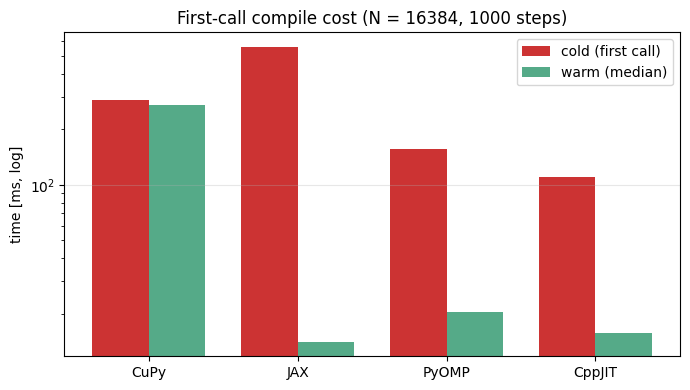

In [2]:
# Cold vs warm for the tools that JIT-compile on the first call.
jit = ["cupy", "jax", "pyomp", "cppjit_gpu_cub"]
jit_labels = {"cupy": "CuPy", "jax": "JAX", "pyomp": "PyOMP",
              "cppjit_gpu_cub": "CppJIT"}
x = np.arange(len(jit)); w = 0.38

fig, ax_c = plt.subplots(figsize=(7, 4))
ax_c.bar(x - w/2, [by_tool[t]["cold_s"] * 1e3 for t in jit], w,
         label="cold (first call)", color="#c33")
ax_c.bar(x + w/2, [by_tool[t]["median_s"] * 1e3 for t in jit], w,
         label="warm (median)", color="#5a8")
ax_c.set_xticks(x); ax_c.set_xticklabels([jit_labels[t] for t in jit])
ax_c.set_yscale("log"); ax_c.set_ylabel("time [ms, log]")
ax_c.set_title("First-call compile cost (N = 16384, 1000 steps)")
ax_c.legend(); ax_c.grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

### <a id="sec3"></a>3. Matched-precision comparison across the memory hierarchy

This is the primary benchmark: every tool runs float64, from `N = 16384` to
`N = 16.7M`. The working set is six fp64 arrays, 48 B per cell: 768 KiB at
the smallest size, 768 MiB at the largest, so the sweep runs from cache into
DRAM on both devices. Throughput is end-to-end for one solver call from
Python, including data transfers; step counts shrink with `N`.

In cache the limit is the float64 arithmetic rate: a float32 solve runs ~6x
faster. In DRAM the C++ kernels approach the bandwidth roof and the float32
gain is ~2x, from halving the bytes.

The plot's cache boundaries use this 48 B model. NumPy's temporaries double
its bytes per cell, so its curve leaves cache ~2x earlier; PyOMP's fused
kernel streams only the four state arrays, so its curve leaves ~1.5x later.

          N         NumPy  CuPy drop-in    CuPy fused           JAX    CppJIT CUB    CppJIT raw         PyOMP        mpi4py      nanobind   Mcells/s
     16,384           103            61          1957           200          1042          1825           791           383          2367
    262,144            74           954          3219          1231          2248          3404           838           740          3687
  1,048,576            60          1709          2905          1677          2317          3136           822           312          2096
  4,194,304            42           841          2632          1794          2219          2704           698           106           823
 16,777,216            41           680          2201          1641          1891          2249           564            62           506


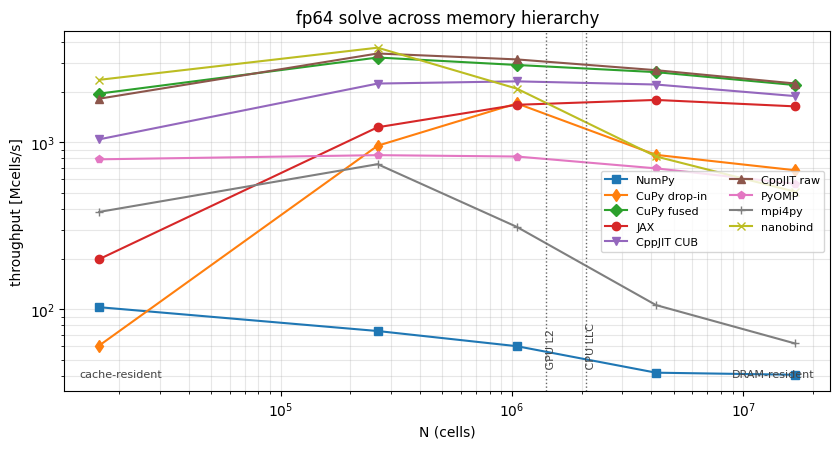

In [3]:
# Matched-precision (float64) comparison, read from timings.json.
import cupy as cp

NAMES = {'08_numpy': 'NumPy', '12_cupy': 'CuPy drop-in',
         '12_cupy_fused': 'CuPy fused', '09_jax_fp64': 'JAX',
         '12_cppjit_gpu_cub': 'CppJIT CUB', '12_cppjit_gpu_raw': 'CppJIT raw',
         '10_pyomp': 'PyOMP', '13_mpi4py': 'mpi4py',
         '11_nanobind': 'nanobind'}
by_stage = {r['stage']: r for r in rows if 'sweep' in r}
missing = [s for s in NAMES if s not in by_stage]
if missing:
    raise SystemExit('no sweep recorded for: ' + ', '.join(missing)
                     + '. Re-run those notebooks, then this one.')

rate = {NAMES[s]: [p['n'] * p['steps'] / p['median_s'] / 1e6
                   for p in by_stage[s]['sweep']] for s in NAMES}
Ns = [p['n'] for p in by_stage[next(iter(NAMES))]['sweep']]
print(f'{"N":>11}' + ''.join(f'{NAMES[s]:>14}' for s in NAMES) + '   Mcells/s')
for j, n_ in enumerate(Ns):
    print(f'{n_:>11,}' + ''.join(f'{rate[NAMES[s]][j]:>14.0f}' for s in NAMES))

fig, ax = plt.subplots(figsize=(8.5, 4.6))
for name, marker in zip(rate, ['s-', 'd-', 'D-', 'o-', 'v-', '^-', 'p-', '+-', 'x-']):
    ax.plot(Ns, rate[name], marker, label=name)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('N (cells)'); ax.set_ylabel('throughput [Mcells/s]')
ax.set_title('fp64 solve across memory hierarchy')

# Cache/DRAM realm boundaries: where the fp64 working set
# (swe_core.working_set_bytes) outgrows each device's last-level cache.
bpc = swe_core.working_set_bytes(1)
llc = swe_core.llc_mib()
realms = [(cp.cuda.runtime.getDeviceProperties(0)['l2CacheSize'] / bpc, 'GPU L2')]
if llc:
    realms.append((llc * 2**20 / bpc, 'CPU LLC'))
for n_b, lbl in realms:
    ax.axvline(n_b, ls=':', color='#666', lw=1)
    ax.text(n_b, ax.get_ylim()[0] * 1.3, f' {lbl}', rotation=90,
            va='bottom', ha='left', fontsize=8, color='#444')
ax.text(0.02, 0.04, 'cache-resident', transform=ax.transAxes, fontsize=8, color='#444')
ax.text(0.98, 0.04, 'DRAM-resident', transform=ax.transAxes, fontsize=8,
        color='#444', ha='right')
ax.legend(ncol=2, fontsize=8); ax.grid(alpha=0.3, which='both')
plt.tight_layout(); plt.show()

#### Where end-to-end time is spent

The rates above include the total cost paid per solver call: building the initial
condition, allocating device buffers, moving data over PCIe, and computing the PDE solution. Step counts shrink as `N` grows, so the fixed share grows with it.
The bars below split the largest size (`N = 16.7M`, 50 steps) for the GPU
tools: compute is the 50-to-100-step slope, the initial condition and the
transfers are measured directly, and allocation + launch overhead is the
remainder.

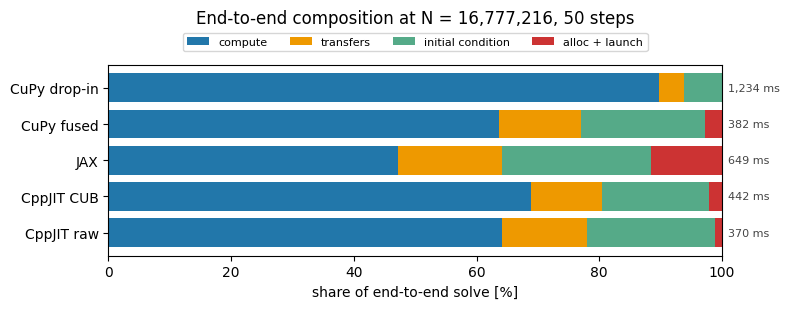

In [4]:
# End-to-end composition at the largest sweep size, recorded by each tool's
# own notebook (swe_core.breakdown_run + save_breakdown).
BSTAGES = ['12_cupy', '12_cupy_fused', '09_jax_fp64',
           '12_cppjit_gpu_cub', '12_cppjit_gpu_raw']
bmissing = [s for s in BSTAGES if 'breakdown' not in by_stage.get(s, {})]
if bmissing:
    raise SystemExit('no breakdown recorded for: ' + ', '.join(bmissing)
                     + '. Re-run those notebooks, then this one.')

PARTS = [('compute_s', 'compute', '#27a'), ('transfer_s', 'transfers', '#e90'),
         ('ic_s', 'initial condition', '#5a8'),
         ('alloc_other_s', 'alloc + launch', '#c33')]
fig, ax = plt.subplots(figsize=(8, 3.2))
ys, left = np.arange(len(BSTAGES)), np.zeros(len(BSTAGES))
for key, lbl, color in PARTS:
    frac = np.array([by_stage[s]['breakdown'][key]
                     / by_stage[s]['breakdown']['total_s']
                     for s in BSTAGES]) * 100
    ax.barh(ys, frac, left=left, color=color, label=lbl)
    left += frac
ax.set_yticks(ys); ax.set_yticklabels([NAMES[s] for s in BSTAGES])
ax.invert_yaxis(); ax.set_xlim(0, 100)
ax.set_xlabel('share of end-to-end solve [%]')
bd0 = by_stage[BSTAGES[0]]['breakdown']
ax.set_title(f"End-to-end composition at N = {bd0['n']:,}, {bd0['steps']} steps", pad=30)
for s, y in zip(BSTAGES, ys):
    ax.text(101, y, f"{by_stage[s]['breakdown']['total_s'] * 1e3:,.0f} ms",
            va='center', fontsize=8, color='#444')
ax.legend(ncols=4, fontsize=8, loc='lower center', bbox_to_anchor=(0.5, 1.04))
plt.tight_layout(); plt.show()

### <a id="sec4"></a>4. Reference: which tool when

The plots rank by throughput; the table is the qualitative counterpart:

| Tool | Use when | Limitation |
|---|---|---|
| **NumPy** | Prototyping, a single CPU thread is enough | Single-threaded, no GPU |
| **CuPy** | Drop-in GPU arrays with the NumPy API | One kernel per elementwise op and Python in the loop, unless hand-fused via `ElementwiseKernel` |
| **JAX** | Fused GPU program from Python, with autodiff | Shape-rigidity: each new input shape pays a fresh XLA compile; optimised for fp32, fp64 takes a significant throughput hit |
| **PyOMP** | Portable C-OpenMP semantics inside `@njit` | Scaling stops at physical cores; scalar per-core rate is arithmetic bound at cache-resident sizes |
| **mpi4py** | Distributing the domain across processes and nodes | Per-step fixed costs dominate as slabs shrink; one NumPy rank per core on a single node |
| **nanobind** | Python entry point to existing C++ codebase | Build-system glue and FFI cost, plus a recompile-on-edit cycle |
| **CppJIT** | Automatic Python/C++ bindings, no wrapper code, GPU support | First-call compile latency, high memory utilisation and parsing cost (JIT overhead) with large translation units |